# 투수 누적 지표 EDA

담당 범위: `asof_pitcher_n`, 누적 제구/코스/결과 비율, 구종 이력 표본 수와 구종군 사용 비율 총 10개 컬럼.


In [1]:
from __future__ import annotations

import json
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
if (cwd / "configs").exists():
    WORKSPACE = cwd
elif (cwd.parent / "configs").exists():
    WORKSPACE = cwd.parent
else:
    WORKSPACE = Path("/home/chanheo/lgaimers/workspace")

os.environ.setdefault("MPLCONFIGDIR", str(WORKSPACE / ".matplotlib"))
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import brier_score_loss

DATA_PATH = WORKSPACE.parent / "open" / "data" / "train.csv"
TEST_PATH = WORKSPACE.parent / "open" / "data" / "test.csv"
OUTPUT_DIR = WORKSPACE / "artifacts" / "eda_pitcher_asof"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET = "control_success"
CONTEXT_COLS = ["season", "pitcher_id", TARGET]
COUNT_COLS = ["asof_pitcher_n", "asof_pitcher_pitchmix_n"]
RATE_COLS = [
    "asof_pitcher_success_rate",
    "asof_pitcher_reverse_rate",
    "asof_pitcher_middle_rate",
    "asof_pitcher_ball_rate",
    "asof_pitcher_strike_rate",
    "asof_pitcher_fastball_rate",
    "asof_pitcher_breaking_rate",
    "asof_pitcher_offspeed_rate",
]
FEATURE_COLS = [
    "asof_pitcher_n",
    "asof_pitcher_success_rate",
    "asof_pitcher_reverse_rate",
    "asof_pitcher_middle_rate",
    "asof_pitcher_ball_rate",
    "asof_pitcher_strike_rate",
    "asof_pitcher_pitchmix_n",
    "asof_pitcher_fastball_rate",
    "asof_pitcher_breaking_rate",
    "asof_pitcher_offspeed_rate",
]

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")
plt.style.use("ggplot")
warnings.filterwarnings("ignore", category=FutureWarning)


def save_figure(name: str) -> None:
    path = FIGURE_DIR / name
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved: {path.relative_to(WORKSPACE)}")


def competition_metrics(y_true: np.ndarray, probability: np.ndarray) -> dict[str, float]:
    probability = np.clip(np.asarray(probability, dtype=float), 0.0, 1.0)
    y_true = np.asarray(y_true, dtype=float)
    brier = float(brier_score_loss(y_true, probability))
    positive_rate = float(y_true.mean())
    baseline_brier = positive_rate * (1.0 - positive_rate)
    skill = 1.0 - brier / baseline_brier
    return {
        "brier_score": brier,
        "baseline_brier_score": baseline_brier,
        "brier_skill_score": float(skill),
        "competition_score": float(max(0.0, 100000.0 * skill)),
    }

print(f"workspace: {WORKSPACE}")
print(f"data: {DATA_PATH}")

workspace: /home/chanheo/lgaimers/workspace
data: /home/chanheo/lgaimers/open/data/train.csv


## 1. 데이터 로딩

전체 49개 컬럼 중 담당 피처 10개와 시간·투수·target만 읽습니다. 통계 집계는 전체 1,475,092행을 사용하고, 그래프 렌더링에만 고정 난수 표본을 사용합니다.

In [2]:
dtype_map = {
    "season": "int16",
    "pitcher_id": "int32",
    TARGET: "int8",
    **{column: "float32" for column in FEATURE_COLS},
}

usecols = CONTEXT_COLS + FEATURE_COLS
df = pd.read_csv(DATA_PATH, usecols=usecols, dtype=dtype_map, encoding="utf-8-sig")
test_columns = pd.read_csv(TEST_PATH, nrows=0, encoding="utf-8-sig").columns.tolist()

assert set(FEATURE_COLS).issubset(test_columns), "test.csv에 담당 피처가 빠져 있습니다."
assert TARGET not in test_columns, "test.csv에는 target이 없어야 합니다."
assert df[TARGET].isin([0, 1]).all(), "target에 0/1 외 값이 있습니다."

print(f"shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"memory: {df.memory_usage(deep=True).sum() / 1024**2:,.1f} MiB")
print(f"seasons: {sorted(df['season'].unique())}")
print(f"pitchers: {df['pitcher_id'].nunique():,}")
print(f"target rate: {df[TARGET].mean():.6f}")
df.head()

shape: 1,475,092 rows x 13 columns
memory: 66.1 MiB
seasons: [np.int16(2019), np.int16(2020), np.int16(2021), np.int16(2022), np.int16(2023), np.int16(2024)]
pitchers: 792
target rate: 0.523766


,season,pitcher_id,asof_pitcher_n,asof_pitcher_success_rate,asof_pitcher_reverse_rate,asof_pitcher_middle_rate,asof_pitcher_ball_rate,asof_pitcher_strike_rate,asof_pitcher_pitchmix_n,asof_pitcher_fastball_rate,asof_pitcher_breaking_rate,asof_pitcher_offspeed_rate,control_success
0,2019,21961,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0
1,2019,21961,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0
2,2019,21961,2.000000,0.000000,0.500000,0.000000,0.500000,0.000000,2.000000,1.000000,0.000000,0.000000,0
3,2019,21961,3.000000,0.000000,0.666667,0.000000,0.333333,0.000000,3.000000,1.000000,0.000000,0.000000,1
4,2019,21961,4.000000,0.250000,0.500000,0.000000,0.250000,0.250000,4.000000,1.000000,0.000000,0.000000,1


## 2. 품질 검사와 구조적 불변식

여기서는 단순 결측률뿐 아니라 “표본 수가 0일 때 rate가 비는가?”, “서로 합이 1이어야 할 비율인가?”, “누적 표본 수가 행 순서에서 감소하는가?”를 확인합니다. 합이 1이 아니라면 오류로 단정하지 않고 컬럼 정의가 상호 배타적인지부터 해석해야 합니다.

In [3]:
quantiles = df[FEATURE_COLS].quantile([0.0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0]).T
feature_summary = pd.DataFrame(index=FEATURE_COLS)
feature_summary["dtype"] = df[FEATURE_COLS].dtypes.astype(str)
feature_summary["n_unique"] = df[FEATURE_COLS].nunique(dropna=True)
feature_summary["missing_n"] = df[FEATURE_COLS].isna().sum()
feature_summary["missing_rate"] = df[FEATURE_COLS].isna().mean()
feature_summary["zero_rate"] = df[FEATURE_COLS].eq(0).mean()
feature_summary["out_of_range_0_1"] = 0
feature_summary.loc[RATE_COLS, "out_of_range_0_1"] = (
    ((df[RATE_COLS] < 0) | (df[RATE_COLS] > 1)).sum().astype(int)
)
feature_summary = feature_summary.join(quantiles.add_prefix("q_"))
feature_summary.to_csv(OUTPUT_DIR / "feature_summary.csv", encoding="utf-8-sig")

def absolute_sum_deviation(columns: list[str]) -> pd.Series:
    valid = df[columns].notna().all(axis=1)
    return (df.loc[valid, columns].sum(axis=1) - 1.0).abs()

ball_strike_deviation = absolute_sum_deviation([
    "asof_pitcher_ball_rate", "asof_pitcher_strike_rate"
])
pitchmix_deviation = absolute_sum_deviation([
    "asof_pitcher_fastball_rate",
    "asof_pitcher_breaking_rate",
    "asof_pitcher_offspeed_rate",
])

pitcher_n_decrease = df.groupby("pitcher_id", sort=False)["asof_pitcher_n"].diff().lt(0)
pitchmix_n_decrease = df.groupby("pitcher_id", sort=False)["asof_pitcher_pitchmix_n"].diff().lt(0)

quality_checks = pd.Series({
    "rows": len(df),
    "rate_range_violation_n": int((((df[RATE_COLS] < 0) | (df[RATE_COLS] > 1)).sum()).sum()),
    "ball_strike_sum_abs_error_mean": float(ball_strike_deviation.mean()),
    "ball_strike_sum_abs_error_gt_1e_6_rate": float(ball_strike_deviation.gt(1e-6).mean()),
    "pitchmix_sum_abs_error_mean": float(pitchmix_deviation.mean()),
    "pitchmix_sum_abs_error_gt_1e_6_rate": float(pitchmix_deviation.gt(1e-6).mean()),
    "pitcher_n_equals_pitchmix_n_rate": float(df["asof_pitcher_n"].eq(df["asof_pitcher_pitchmix_n"]).mean()),
    "pitcher_n_decrease_rows": int(pitcher_n_decrease.sum()),
    "pitchmix_n_decrease_rows": int(pitchmix_n_decrease.sum()),
})
quality_checks.rename("value").to_csv(OUTPUT_DIR / "quality_checks.csv", encoding="utf-8-sig")

cold_start = pd.DataFrame({
    "condition": [
        "pitcher_n_zero",
        "pitcher_n_zero_success_missing",
        "pitcher_n_positive_success_missing",
        "pitchmix_n_zero",
        "pitchmix_n_zero_all_mix_missing",
        "pitchmix_n_positive_any_mix_missing",
    ],
    "rows": [
        int(df["asof_pitcher_n"].eq(0).sum()),
        int((df["asof_pitcher_n"].eq(0) & df["asof_pitcher_success_rate"].isna()).sum()),
        int((df["asof_pitcher_n"].gt(0) & df["asof_pitcher_success_rate"].isna()).sum()),
        int(df["asof_pitcher_pitchmix_n"].eq(0).sum()),
        int((df["asof_pitcher_pitchmix_n"].eq(0) & df[[
            "asof_pitcher_fastball_rate", "asof_pitcher_breaking_rate", "asof_pitcher_offspeed_rate"
        ]].isna().all(axis=1)).sum()),
        int((df["asof_pitcher_pitchmix_n"].gt(0) & df[[
            "asof_pitcher_fastball_rate", "asof_pitcher_breaking_rate", "asof_pitcher_offspeed_rate"
        ]].isna().any(axis=1)).sum()),
    ],
})
cold_start["rate"] = cold_start["rows"] / len(df)
cold_start.to_csv(OUTPUT_DIR / "cold_start_summary.csv", index=False, encoding="utf-8-sig")

display(feature_summary)
display(quality_checks.to_frame("value"))
display(cold_start)

,dtype,n_unique,missing_n,missing_rate,zero_rate,out_of_range_0_1,q_0.0,q_0.01,q_0.05,q_0.25,q_0.5,q_0.75,q_0.95,q_0.99,q_1.0
asof_pitcher_n,float32,15450,0,0.000000,0.000537,0,0.000000,18.000000,103.000000,684.000000,"1,776.000000","3,725.000000","8,530.000000","11,870.000000","15,449.000000"
asof_pitcher_success_rate,float32,220896,792,0.000537,0.000507,0,0.000000,0.395062,0.447228,0.499073,0.532022,0.569045,0.632058,0.703825,1.000000
asof_pitcher_reverse_rate,float32,228112,792,0.000537,0.003419,0,0.000000,0.065068,0.119048,0.178940,0.218025,0.251064,0.307958,0.362857,1.000000
asof_pitcher_middle_rate,float32,120993,792,0.000537,0.004154,0,0.000000,0.056075,0.095477,0.125644,0.141903,0.157025,0.187036,0.221184,1.000000
asof_pitcher_ball_rate,float32,144809,792,0.000537,0.000614,0,0.000000,0.283333,0.319377,0.348091,0.369369,0.392166,0.434211,0.488550,1.000000
asof_pitcher_strike_rate,float32,131532,792,0.000537,0.000660,0,0.000000,0.333333,0.387387,0.423077,0.442289,0.462441,0.495146,0.521127,1.000000
asof_pitcher_pitchmix_n,float32,15450,0,0.000000,0.000537,0,0.000000,18.000000,103.000000,684.000000,"1,776.000000","3,725.000000","8,530.000000","11,870.000000","15,449.000000"
asof_pitcher_fastball_rate,float32,337588,792,0.000537,0.000132,0,0.000000,0.346296,0.406906,0.486486,0.544041,0.613636,0.729738,0.828947,1.000000
asof_pitcher_breaking_rate,float32,386613,792,0.000537,0.003011,0,0.000000,0.046216,0.103250,0.215859,0.289301,0.361801,0.466150,0.549296,1.000000
asof_pitcher_offspeed_rate,float32,449454,792,0.000537,0.027473,0,0.000000,0.000000,0.005348,0.075000,0.140563,0.217011,0.364815,0.466447,1.000000


,value
rows,"1,475,092.000000"
rate_range_violation_n,0.000000
ball_strike_sum_abs_error_mean,0.185881
ball_strike_sum_abs_error_gt_1e_6_rate,0.997443
pitchmix_sum_abs_error_mean,0.000000
pitchmix_sum_abs_error_gt_1e_6_rate,0.063822
pitcher_n_equals_pitchmix_n_rate,1.000000
pitcher_n_decrease_rows,0.000000
pitchmix_n_decrease_rows,0.000000


,condition,rows,rate
0,pitcher_n_zero,792,0.000537
1,pitcher_n_zero_success_missing,792,0.000537
2,pitcher_n_positive_success_missing,0,0.000000
3,pitchmix_n_zero,792,0.000537
4,pitchmix_n_zero_all_mix_missing,792,0.000537
5,pitchmix_n_positive_any_mix_missing,0,0.000000


## 3. 개별 분포와 소표본 효과

누적 표본 수는 긴 꼬리가 예상되므로 원본 대신 `log1p` 축도 함께 봅니다. rate의 0/1 집중은 실제 성향일 수도 있지만, 작은 분모에서 생기는 불안정성일 수도 있으므로 표본 수 구간별 분산과 극단값 비율을 비교합니다.

saved: artifacts/eda_pitcher_asof/figures/01_feature_distributions.png


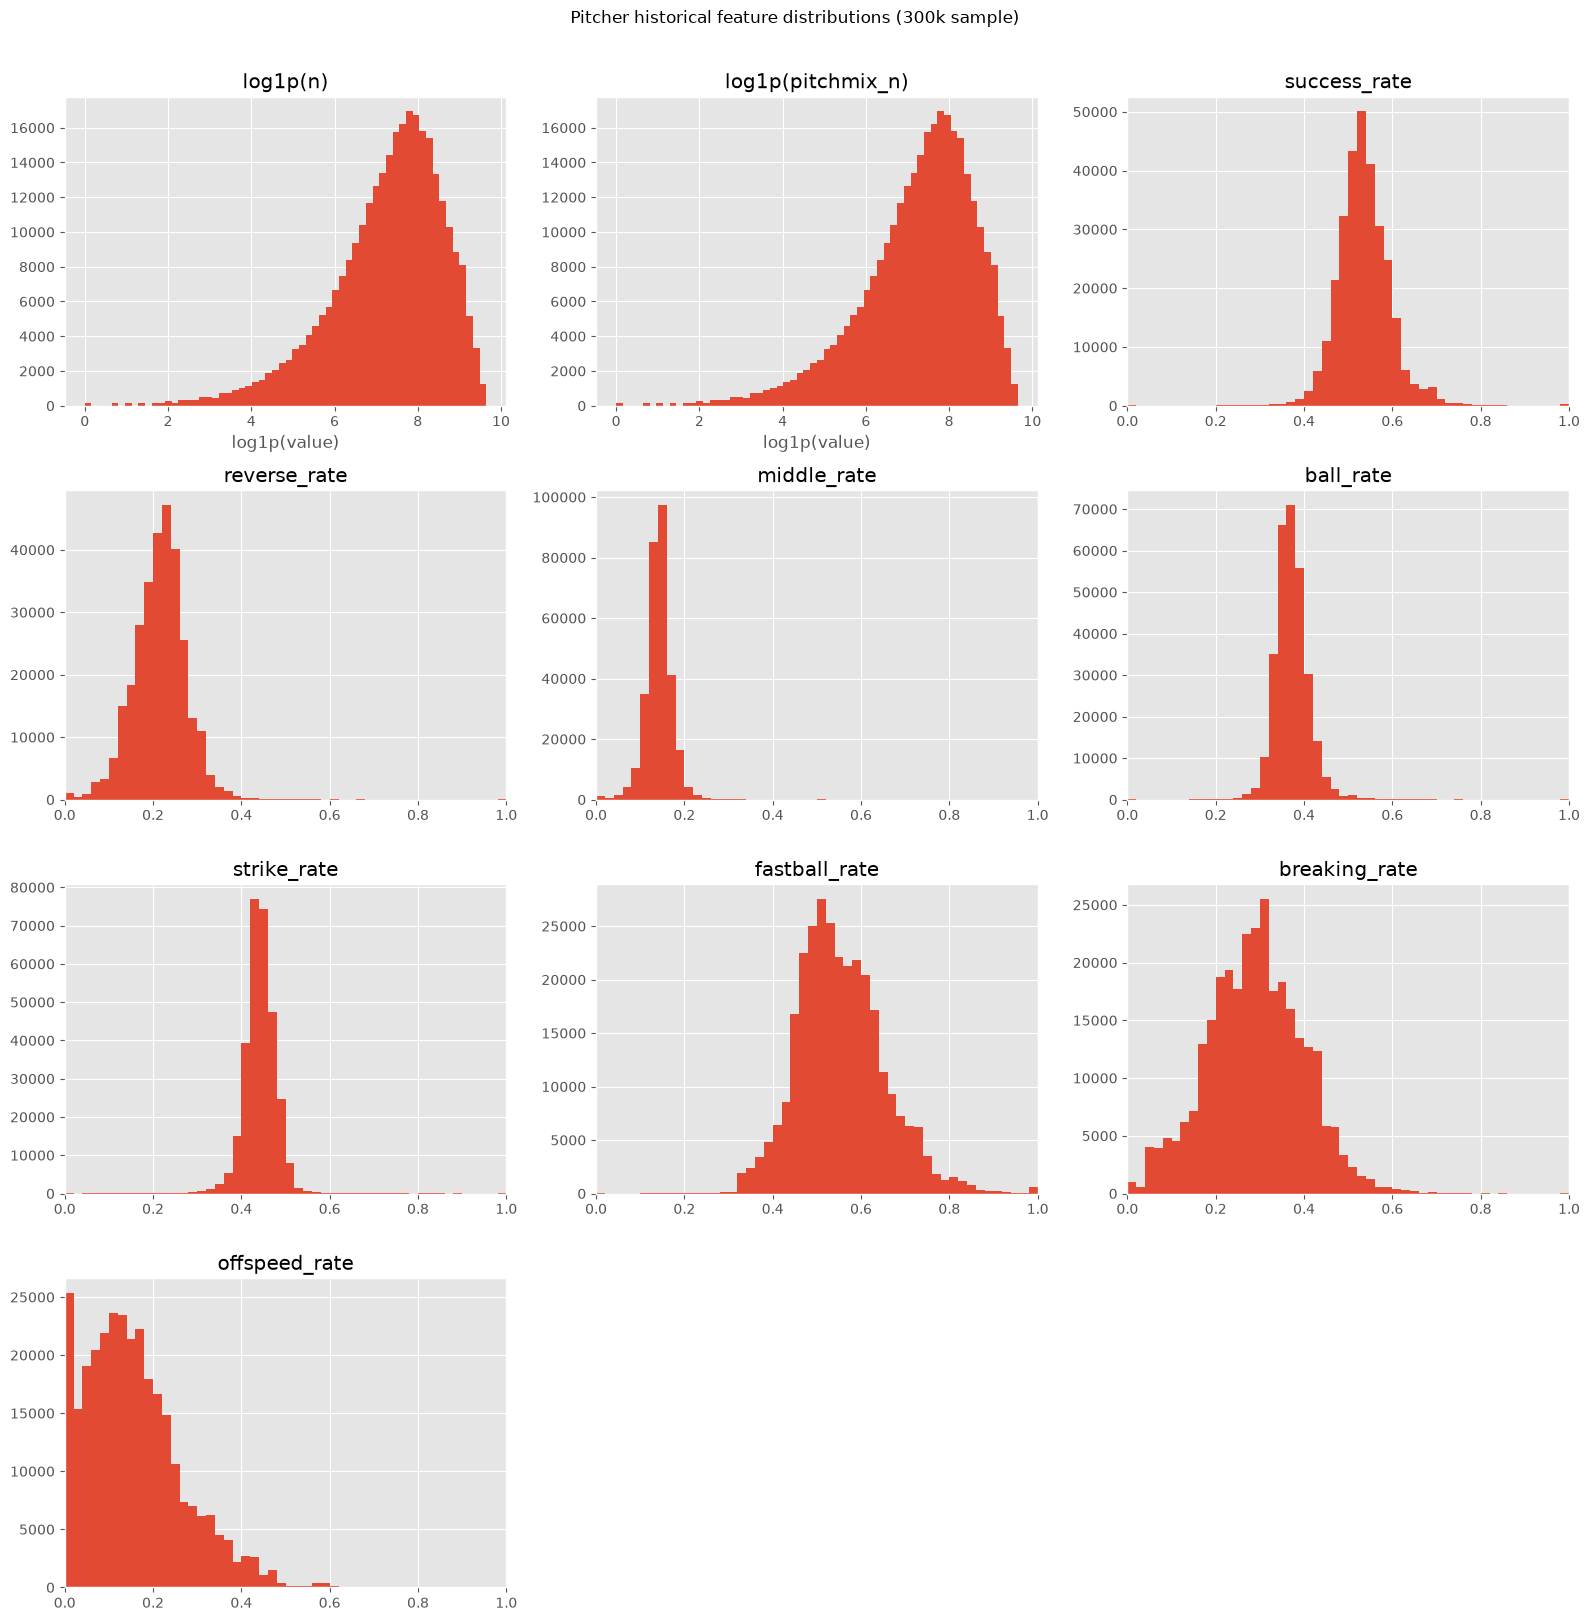

,feature,n_bin,rows,non_missing,mean,std,target_rate,extreme_0_or_1_rate
0,asof_pitcher_success_rate,0,792,0,NaN,NaN,0.551768,0.000000
1,asof_pitcher_success_rate,1,792,792,0.551768,0.497627,0.537879,1.000000
2,asof_pitcher_success_rate,2-10,7104,7104,0.540704,0.251609,0.545467,0.142033
3,asof_pitcher_success_rate,11-30,15291,15291,0.546090,0.152933,0.549539,0.000458
4,asof_pitcher_success_rate,31-100,48229,48229,0.543770,0.109005,0.537436,0.000000
5,asof_pitcher_success_rate,101-300,115971,115971,0.538665,0.077554,0.538160,0.000000
6,asof_pitcher_success_rate,301-1000,307236,307236,0.536103,0.060933,0.529489,0.000000
7,asof_pitcher_success_rate,1001+,979677,979677,0.533904,0.047382,0.519001,0.000000


In [4]:
plot_df = df.sample(n=min(300_000, len(df)), random_state=RANDOM_STATE)
short_names = {column: column.replace("asof_pitcher_", "") for column in FEATURE_COLS}

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.ravel()
for index, column in enumerate(COUNT_COLS):
    values = np.log1p(plot_df[column].dropna())
    axes[index].hist(values, bins=60)
    axes[index].set_title(f"log1p({short_names[column]})")
    axes[index].set_xlabel("log1p(value)")
for index, column in enumerate(RATE_COLS, start=2):
    axes[index].hist(plot_df[column].dropna(), bins=np.linspace(0, 1, 51))
    axes[index].set_title(short_names[column])
    axes[index].set_xlim(0, 1)
for axis in axes[len(FEATURE_COLS):]:
    axis.axis("off")
fig.suptitle("Pitcher historical feature distributions (300k sample)", y=1.01)
plt.tight_layout()
save_figure("01_feature_distributions.png")
plt.show()

sample_bins = [-0.1, 0, 1, 10, 30, 100, 300, 1_000, np.inf]
sample_labels = ["0", "1", "2-10", "11-30", "31-100", "101-300", "301-1000", "1001+"]
sample_size_bin = pd.cut(
    df["asof_pitcher_n"], bins=sample_bins, labels=sample_labels, include_lowest=True
)

sample_size_rows = []
for column in RATE_COLS:
    grouped = pd.DataFrame({"n_bin": sample_size_bin, "value": df[column], "target": df[TARGET]}).groupby(
        "n_bin", observed=False
    )
    summary = grouped.agg(
        rows=("value", "size"),
        non_missing=("value", "count"),
        mean=("value", "mean"),
        std=("value", "std"),
        target_rate=("target", "mean"),
    ).reset_index()
    extreme = pd.DataFrame({
        "n_bin": sample_size_bin,
        "extreme": df[column].isin([0.0, 1.0]),
    }).groupby("n_bin", observed=False)["extreme"].mean().reset_index(name="extreme_0_or_1_rate")
    summary = summary.merge(extreme, on="n_bin", how="left")
    summary.insert(0, "feature", column)
    sample_size_rows.append(summary)

sample_size_effect = pd.concat(sample_size_rows, ignore_index=True)
sample_size_effect.to_csv(OUTPUT_DIR / "sample_size_effect.csv", index=False, encoding="utf-8-sig")
display(sample_size_effect[sample_size_effect["feature"] == "asof_pitcher_success_rate"])

## 4. 시간 변화와 변수 간 관계

전체 상관은 연도별 target drift에 의해 왜곡될 수 있습니다. 먼저 연도별 중심과 결측률을 확인한 뒤, 강한 상관쌍은 정의상 중복인지 모델에 유용한 interaction 후보인지 구분합니다.

saved: artifacts/eda_pitcher_asof/figures/02_season_drift.png


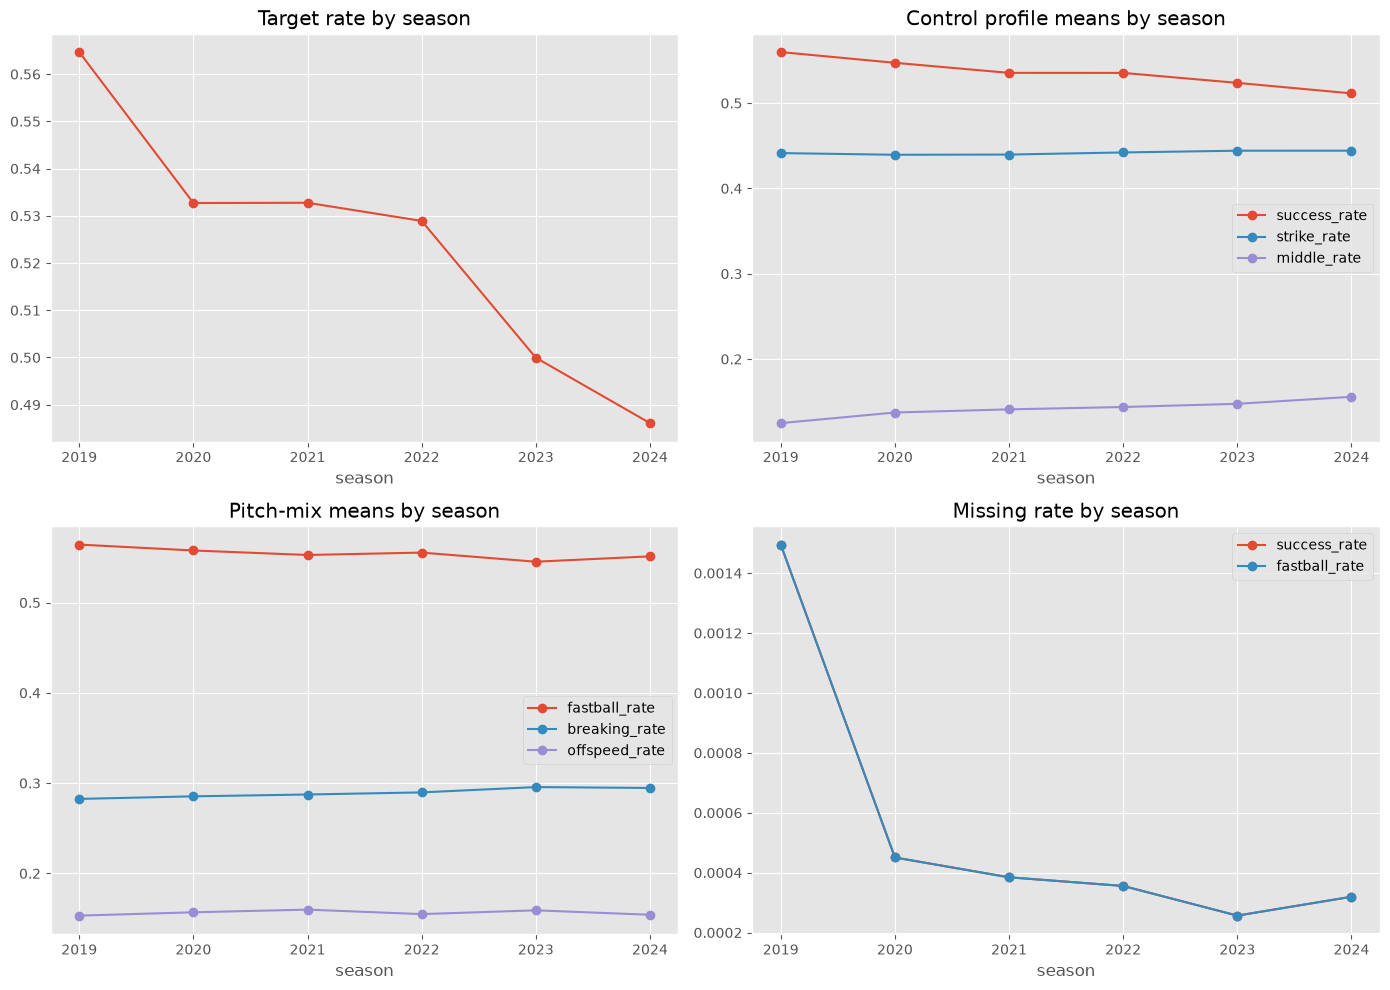

saved: artifacts/eda_pitcher_asof/figures/03_correlation.png


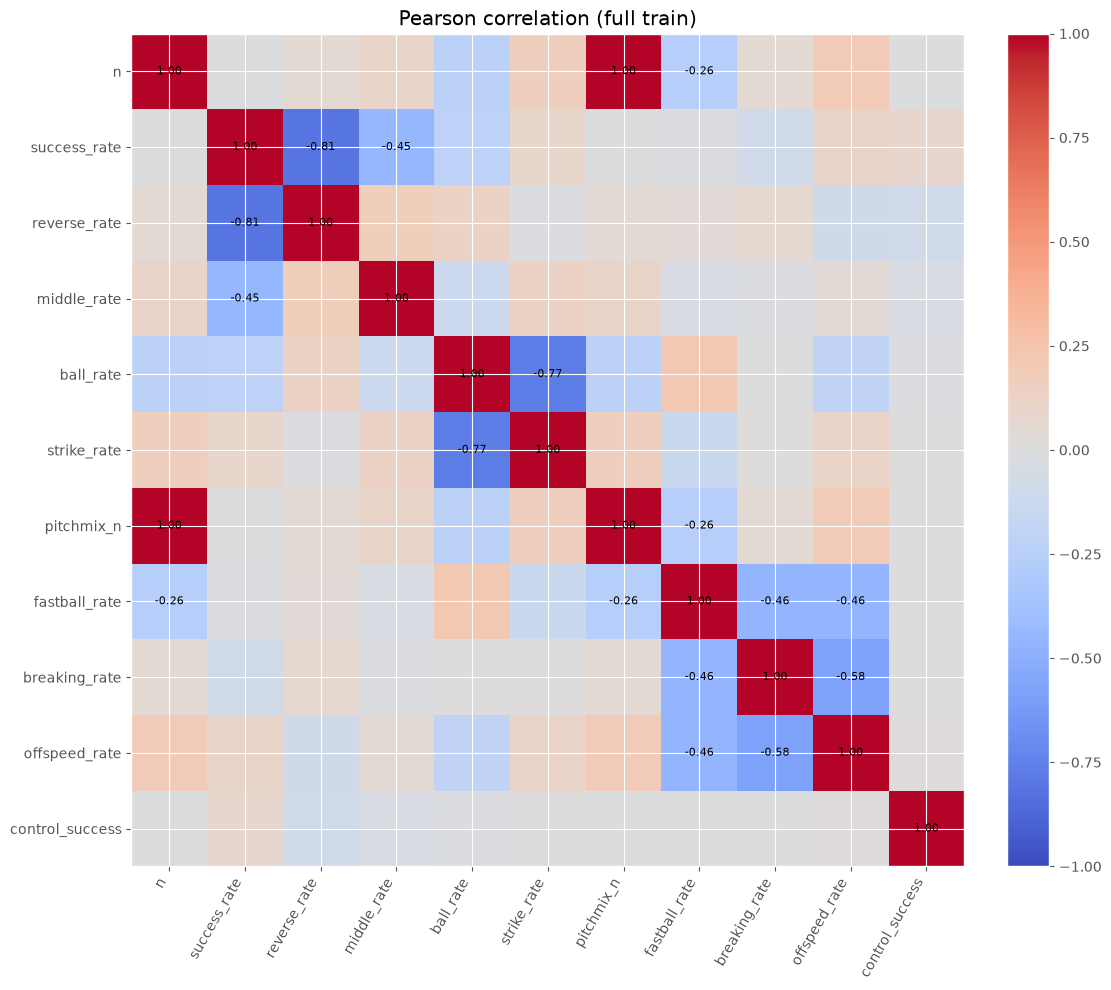

saved: artifacts/eda_pitcher_asof/figures/04_selected_feature_pairs.png


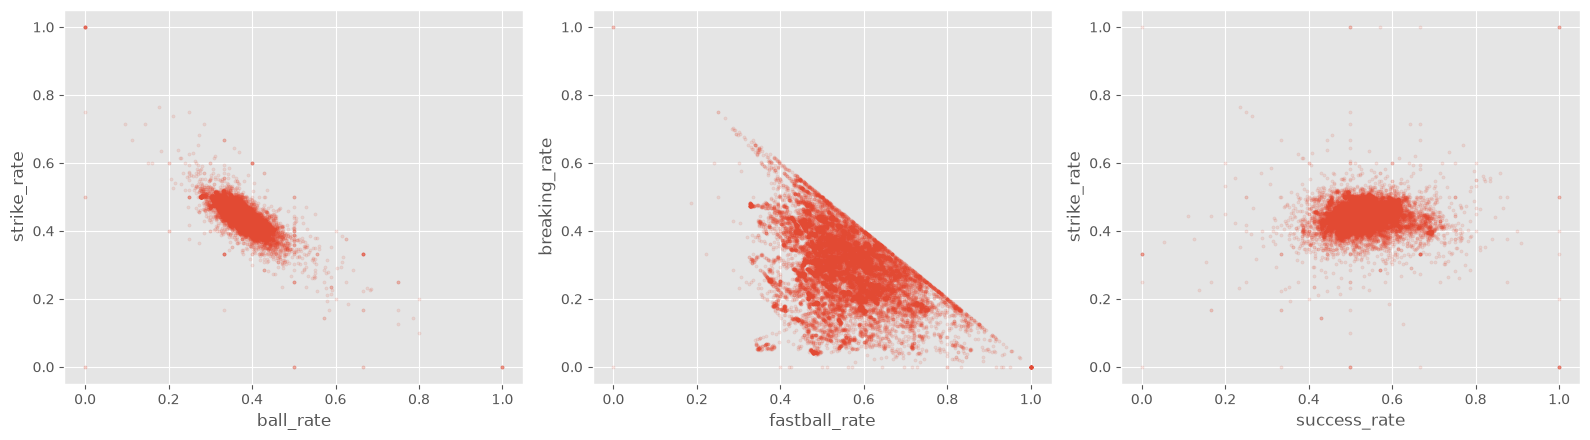

,season,asof_pitcher_n_mean,asof_pitcher_n_median,asof_pitcher_success_rate_mean,asof_pitcher_success_rate_median,asof_pitcher_reverse_rate_mean,asof_pitcher_reverse_rate_median,asof_pitcher_middle_rate_mean,asof_pitcher_middle_rate_median,asof_pitcher_ball_rate_mean,asof_pitcher_ball_rate_median,asof_pitcher_strike_rate_mean,asof_pitcher_strike_rate_median,asof_pitcher_pitchmix_n_mean,asof_pitcher_pitchmix_n_median,asof_pitcher_fastball_rate_mean,asof_pitcher_fastball_rate_median,asof_pitcher_breaking_rate_mean,asof_pitcher_breaking_rate_median,asof_pitcher_offspeed_rate_mean,asof_pitcher_offspeed_rate_median,control_success_mean,control_success_median,asof_pitcher_n_missing_rate,asof_pitcher_success_rate_missing_rate,asof_pitcher_reverse_rate_missing_rate,asof_pitcher_middle_rate_missing_rate,asof_pitcher_ball_rate_missing_rate,asof_pitcher_strike_rate_missing_rate,asof_pitcher_pitchmix_n_missing_rate,asof_pitcher_fastball_rate_missing_rate,asof_pitcher_breaking_rate_missing_rate,asof_pitcher_offspeed_rate_missing_rate
0,2019,768.728333,571.000000,0.559821,0.557377,0.182268,0.180894,0.124872,0.125000,0.368942,0.365890,0.441408,0.443182,768.728333,571.000000,0.564289,0.547826,0.282509,0.280293,0.153202,0.140175,0.564670,1.000000,0.000000,0.001495,0.001495,0.001495,0.001495,0.001495,0.000000,0.001495,0.001495,0.001495
1,2020,"1,714.690308","1,374.000000",0.547245,0.544206,0.191926,0.191565,0.137305,0.134718,0.369969,0.364706,0.439449,0.440529,"1,714.690308","1,374.000000",0.557751,0.542258,0.285365,0.284753,0.156884,0.140085,0.532712,1.000000,0.000000,0.000451,0.000451,0.000451,0.000451,0.000451,0.000000,0.000451,0.000451,0.000451
2,2021,"2,369.192627","1,869.000000",0.535459,0.535248,0.221345,0.220443,0.140985,0.140125,0.377340,0.372853,0.439692,0.440811,"2,369.192627","1,869.000000",0.552764,0.543669,0.287387,0.283644,0.159849,0.141518,0.532762,1.000000,0.000000,0.000384,0.000384,0.000384,0.000384,0.000384,0.000000,0.000384,0.000384,0.000384
3,2022,"3,194.707275","2,518.000000",0.535402,0.531092,0.223366,0.225352,0.143750,0.144309,0.373165,0.370834,0.442170,0.441700,"3,194.707275","2,518.000000",0.555407,0.546857,0.289721,0.293551,0.154873,0.138889,0.528920,1.000000,0.000000,0.000356,0.000356,0.000356,0.000356,0.000356,0.000000,0.000356,0.000356,0.000356
4,2023,"3,880.774414","3,073.000000",0.523730,0.522202,0.233023,0.234439,0.147506,0.146986,0.371237,0.367177,0.444210,0.445300,"3,880.774414","3,073.000000",0.545318,0.536920,0.295620,0.299918,0.159062,0.142662,0.499957,0.000000,0.000000,0.000257,0.000257,0.000257,0.000257,0.000257,0.000000,0.000257,0.000257,0.000257
5,2024,"3,928.214600","2,942.000000",0.511397,0.510554,0.237246,0.235294,0.155704,0.153455,0.372625,0.372748,0.444229,0.441572,"3,928.214600","2,942.000000",0.551235,0.548377,0.294624,0.295213,0.154141,0.138985,0.486105,0.000000,0.000000,0.000320,0.000320,0.000320,0.000320,0.000320,0.000000,0.000320,0.000320,0.000320


In [5]:
yearly_center = df.groupby("season")[FEATURE_COLS + [TARGET]].agg(["mean", "median"])
yearly_center.columns = [f"{column}_{stat}" for column, stat in yearly_center.columns]
yearly_missing = df.groupby("season")[FEATURE_COLS].apply(lambda group: group.isna().mean())
yearly_missing.columns = [f"{column}_missing_rate" for column in yearly_missing.columns]
yearly_summary = yearly_center.join(yearly_missing).reset_index()
yearly_summary.to_csv(OUTPUT_DIR / "yearly_summary.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
yearly_summary.plot(x="season", y=f"{TARGET}_mean", marker="o", ax=axes[0, 0], legend=False)
axes[0, 0].set_title("Target rate by season")
for column in ["asof_pitcher_success_rate", "asof_pitcher_strike_rate", "asof_pitcher_middle_rate"]:
    yearly_summary.plot(x="season", y=f"{column}_mean", marker="o", ax=axes[0, 1], label=short_names[column])
axes[0, 1].set_title("Control profile means by season")
for column in ["asof_pitcher_fastball_rate", "asof_pitcher_breaking_rate", "asof_pitcher_offspeed_rate"]:
    yearly_summary.plot(x="season", y=f"{column}_mean", marker="o", ax=axes[1, 0], label=short_names[column])
axes[1, 0].set_title("Pitch-mix means by season")
for column in ["asof_pitcher_success_rate", "asof_pitcher_fastball_rate"]:
    yearly_summary.plot(x="season", y=f"{column}_missing_rate", marker="o", ax=axes[1, 1], label=short_names[column])
axes[1, 1].set_title("Missing rate by season")
plt.tight_layout()
save_figure("02_season_drift.png")
plt.show()

correlation = df[FEATURE_COLS + [TARGET]].corr()
correlation.to_csv(OUTPUT_DIR / "correlation.csv", encoding="utf-8-sig")
fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(correlation, vmin=-1, vmax=1, cmap="coolwarm")
labels = [column.replace("asof_pitcher_", "") for column in correlation.columns]
ax.set_xticks(range(len(labels)), labels=labels, rotation=60, ha="right")
ax.set_yticks(range(len(labels)), labels=labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        if abs(value) >= 0.25 or row == column:
            ax.text(column, row, f"{value:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Pearson correlation (full train)")
plt.tight_layout()
save_figure("03_correlation.png")
plt.show()

pair_sample = plot_df.sample(n=min(20_000, len(plot_df)), random_state=RANDOM_STATE)
pairs = [
    ("asof_pitcher_ball_rate", "asof_pitcher_strike_rate"),
    ("asof_pitcher_fastball_rate", "asof_pitcher_breaking_rate"),
    ("asof_pitcher_success_rate", "asof_pitcher_strike_rate"),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for axis, (x_column, y_column) in zip(axes, pairs):
    axis.scatter(pair_sample[x_column], pair_sample[y_column], s=5, alpha=0.12)
    axis.set_xlabel(short_names[x_column])
    axis.set_ylabel(short_names[y_column])
plt.tight_layout()
save_figure("04_selected_feature_pairs.png")
plt.show()

display(yearly_summary)

## 5. Target 관계

각 rate를 분위수 구간으로 나누고 `control_success` 평균과 95% 근사 오차막대를 봅니다. 선형 상관계수 하나로 끝내지 않고, 비선형성·표본 수·연도 조건에서도 방향이 유지되는지 확인합니다.

saved: artifacts/eda_pitcher_asof/figures/05_target_by_feature_quantile.png


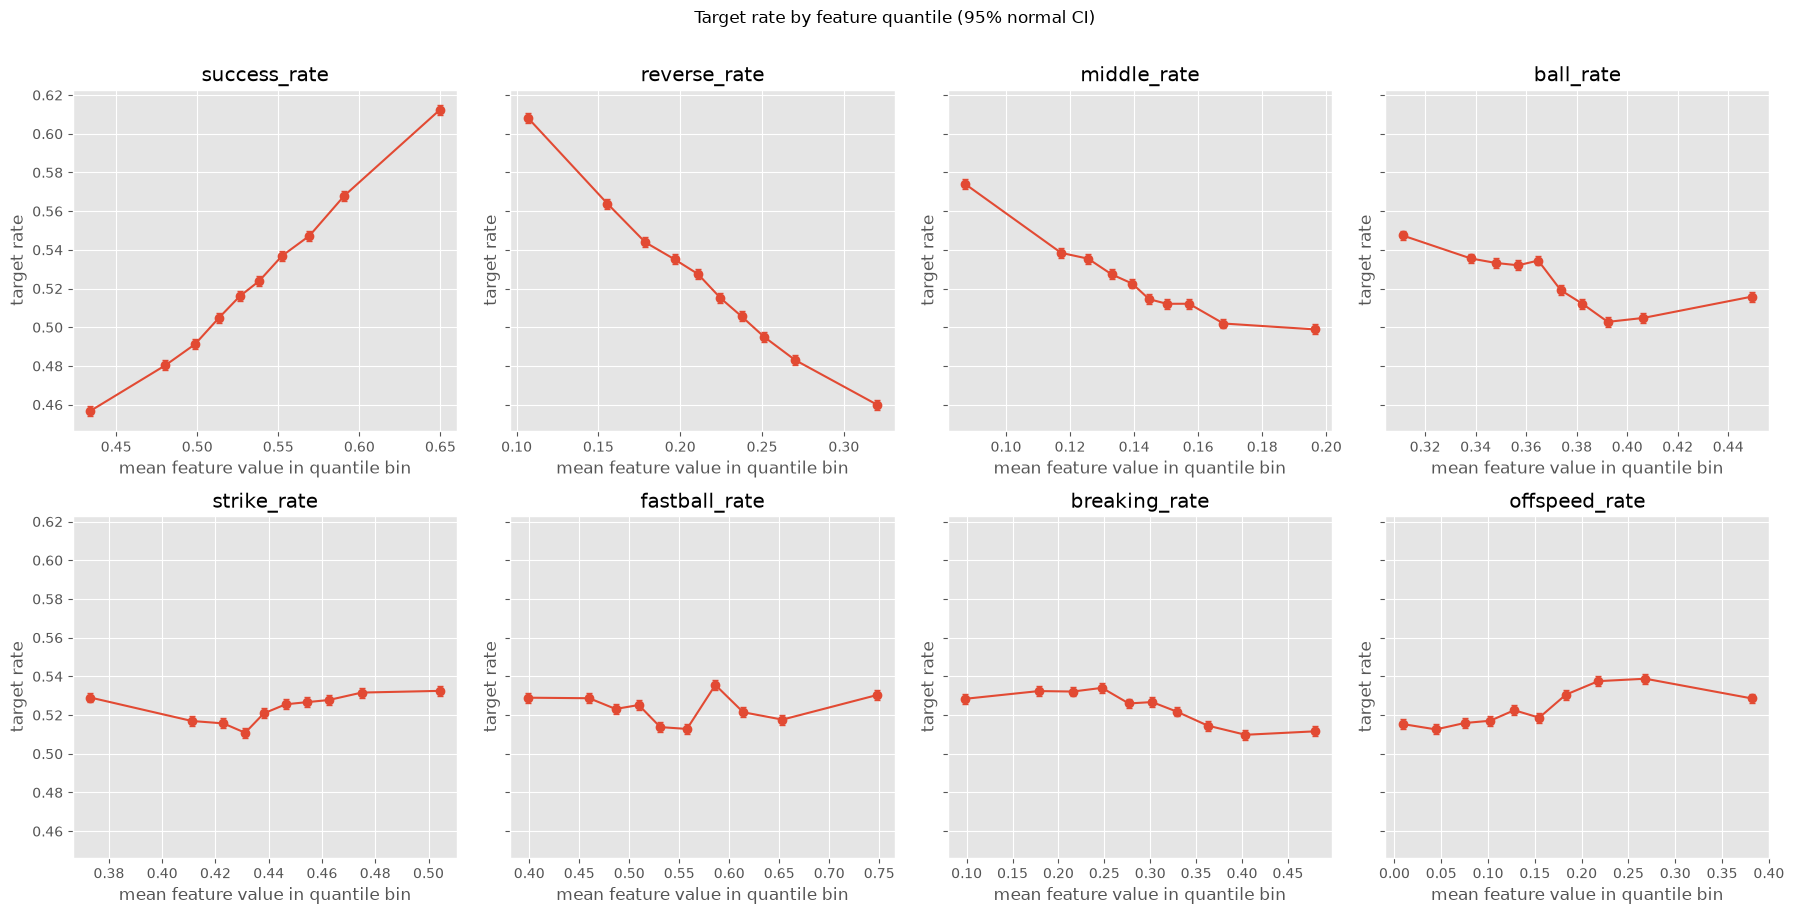

season,2019,2020,2021,2022,2023,2024
feature,,,,,,
asof_pitcher_ball_rate,-0.009539,-0.022883,0.001084,0.014252,-0.047391,-0.041287
asof_pitcher_breaking_rate,-0.011479,-0.005526,-0.009821,-0.013030,-0.012311,-0.017239
asof_pitcher_fastball_rate,-0.005060,-0.014804,0.004275,0.018689,-0.008205,-0.011175
asof_pitcher_middle_rate,-0.038774,-0.008178,-0.028389,-0.037832,-0.006822,-0.012940
asof_pitcher_offspeed_rate,0.016318,0.019742,0.005826,-0.004447,0.019404,0.028287
asof_pitcher_reverse_rate,-0.078066,-0.059002,-0.073911,-0.094623,-0.049934,-0.054520
asof_pitcher_strike_rate,-0.002039,0.010665,-0.011870,-0.023918,0.035371,0.030032
asof_pitcher_success_rate,0.094350,0.061158,0.078384,0.098593,0.052714,0.057601


In [6]:
target_by_bin_rows = []
target_by_bin_season_rows = []
within_season_correlations = []

for feature in RATE_COLS:
    valid = df[feature].notna()
    quantile_bin = pd.qcut(df.loc[valid, feature], q=10, duplicates="drop")
    temporary = pd.DataFrame({
        "feature_value": df.loc[valid, feature],
        TARGET: df.loc[valid, TARGET],
        "season": df.loc[valid, "season"],
        "bin": quantile_bin,
    })
    overall = temporary.groupby("bin", observed=True).agg(
        rows=(TARGET, "size"),
        feature_mean=("feature_value", "mean"),
        feature_min=("feature_value", "min"),
        feature_max=("feature_value", "max"),
        target_rate=(TARGET, "mean"),
    ).reset_index()
    overall["target_se"] = np.sqrt(
        overall["target_rate"] * (1.0 - overall["target_rate"]) / overall["rows"]
    )
    overall["feature"] = feature
    overall["bin_order"] = np.arange(len(overall))
    overall["bin"] = overall["bin"].astype(str)
    target_by_bin_rows.append(overall)

    seasonal = temporary.groupby(["season", "bin"], observed=True).agg(
        rows=(TARGET, "size"),
        feature_mean=("feature_value", "mean"),
        target_rate=(TARGET, "mean"),
    ).reset_index()
    seasonal["feature"] = feature
    seasonal["bin"] = seasonal["bin"].astype(str)
    target_by_bin_season_rows.append(seasonal)

    for season, group in temporary.groupby("season"):
        within_season_correlations.append({
            "feature": feature,
            "season": int(season),
            "pearson_with_target": float(group["feature_value"].corr(group[TARGET])),
            "rows": len(group),
        })

target_by_bin = pd.concat(target_by_bin_rows, ignore_index=True)
target_by_bin_season = pd.concat(target_by_bin_season_rows, ignore_index=True)
within_season_correlation = pd.DataFrame(within_season_correlations)
target_by_bin.to_csv(OUTPUT_DIR / "target_by_bin.csv", index=False, encoding="utf-8-sig")
target_by_bin_season.to_csv(OUTPUT_DIR / "target_by_bin_season.csv", index=False, encoding="utf-8-sig")
within_season_correlation.to_csv(OUTPUT_DIR / "within_season_target_correlation.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharey=True)
for axis, feature in zip(axes.ravel(), RATE_COLS):
    feature_data = target_by_bin[target_by_bin["feature"] == feature]
    axis.errorbar(
        feature_data["feature_mean"],
        feature_data["target_rate"],
        yerr=1.96 * feature_data["target_se"],
        marker="o",
        capsize=2,
    )
    axis.set_title(short_names[feature])
    axis.set_xlabel("mean feature value in quantile bin")
    axis.set_ylabel("target rate")
fig.suptitle("Target rate by feature quantile (95% normal CI)", y=1.01)
plt.tight_layout()
save_figure("05_target_by_feature_quantile.png")
plt.show()

display(within_season_correlation.pivot(index="feature", columns="season", values="pearson_with_target"))